## Lista 1b comentada e atualizada

In [58]:
## Importação das bibliotecas Python, como indicado no texto ##

# biblioteca Python para matemática simbólica 
import sympy as sym
from sympy import* 

# Pacote para computação científica
import numpy as np

# biblioteca para a visualização de dados em Python.
import matplotlib.pyplot as plt

from pylab import plot, show

# Este módulo fornece acesso às funções matemáticas (definidas pelo padrão C)
import math

# cmath permite operações com números complexos
import cmath

# O módulo de frações fornece suporte para aritmética de números racionais
from fractions import Fraction

# permite usar latex para exibir equações matemáticas no Jupyter Notebook
from IPython.display import display, Math

#toolbox de processamento de sinais
from scipy import signal 

## $2^a$ Lista de Exercícios

**Exercício 2.12** Considere o sinal a tempo discreto $f(k)=(1 / 2)^{|k-2|}$ definido para todo $k \in \mathbb{Z}$.

a) Determine a sua componente par $f_p(k)$ e a sua componente ímpar $f_i(k)$.

 **a)** 
 $$
 f_p(k) = \frac{1}{2}\left((1 / 2)^{|k-2|} + (1 / 2)^{|-k-2|}\right) = (1 / 2)^{|k-2|+1} + (1 / 2)^{|-k-2|+1}
 $$
 e
$$
f_i(k) = \frac{1}{2}\left((1 / 2)^{|k-2|} - (1 / 2)^{|-k-2|}\right) = (1 / 2)^{|k-2|+1} - (1 / 2)^{|-k-2|+1}
$$




b) Em um mesmo gráfico, esboce $f(k), f_p(k)$ e $f_i(k)$ para $-5 \leq k \leq 5$.

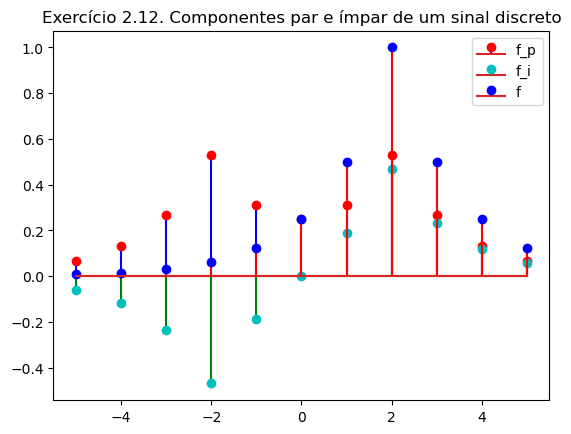

In [59]:
z = []
z1 = []
z2 = []
for k in range(-5,6):
    z.append(k)
    z1.append(0.5**(abs(k -2)))
    z2.append(0.5**(abs(- k -2)))
s1 = z1
s2 = [(a + b)*0.5 for a, b in zip(z1, z2)]
s3 = [(a - b)*0.5 for a, b in zip(z1, z2)]

plt.stem(z, s2, 'b', markerfmt='ro', label='f_p')
plt.stem(z, s3, 'g', markerfmt='co', label='f_i')
plt.stem(z, s1, 'r', markerfmt='bo', label='f')
plt.legend()
plt.title('Exercício 2.12. Componentes par e ímpar de um sinal discreto')
plt.show()

c) Para cada um dos sinais $f(k), f_p(k)$ e $f_i(k)$ determine $E, E_p$ e $E_i$.

Por definição, temos que 

$$E = \sum_{k = -\infty}^{+ \infty} f^2, \quad E_p = \sum_{k = -\infty}^{+ \infty} f_p^2 \quad \text{ e } \quad E_i = \sum_{k = -\infty}^{+ \infty} f_i^2.  $$

Assim, temos

$$E = \sum_{k = -\infty}^{+ \infty} (1 / 2)^{2|k-2|} = \sum_{k = -\infty}^{+ \infty} (1 / 4)^{|n|},$$
onde realizamos a mudança de variáveis $n = k-2$.
Finalmente, podemos escrever 
$$E =  2\sum_{n = 0}^{+ \infty} (1 / 4)^{n} - 1 = 2\frac{1}{1 - \frac{1}{4}} - 1 = \frac{5}{3}.$$



In [60]:
k = sym.Symbol('k')
f = 0.5**(abs(k))
E = 2*Sum(f**2,(k,0,oo)).doit()
E - 1

5/3

Por outro lado, 

$$E_p = \frac{1}{4}\sum_{k = -\infty}^{+ \infty}  \frac{1}{4}^{|k-2|} + \frac{1}{4}\sum_{k = -\infty}^{+ \infty}  \frac{1}{4}^{|-k-2|} = \frac{1}{4}E + \frac{1}{4}\sum_{k = -\infty}^{+ \infty}  \frac{1}{4}^{|-k-2|}= \frac{1}{4}E + \frac{1}{4}\sum_{n = - \infty}^{+ \infty}  \frac{1}{4}^{|n|},$$
onde realizamos a mudança de variáveis $n = -k-2$ e usamos o fato de que $\left\langle f_p,f_i \right\rangle = 0.$

Assim, concluímos que
$$E_p =  \frac{1}{2}E = \frac{5}{6}.$$

Analogamente, observamos que 

$$E_i =  \frac{1}{2}E = \frac{5}{6}.$$

d) Qual é a relação que existe entre $E$ e $E_p+E_i$? Esta relação é válida para qualquer sinal $f(k)$ dado?

A relação é dada por 

$$E = E_p + E_i$$ 
e é válida para qualquer sinal dado. Este fato é uma consequência direta de $\left\langle f_p,f_i \right\rangle = 0.$


e) Considerando $f(k)=g(k)+h(k)$, qual é a condição para assegurar que $E_f=$ $E_g+E_h$ ?

A condição é que $g$ e $h$ serjam ortogonais. 

De fato, 
$$E_f = \left\langle g + h,g + h \right\rangle = \underbrace{\left\langle g ,g \right\rangle}_{E_g} + \underbrace{\left\langle h,h \right\rangle}_{E_h}
\Leftrightarrow  \left\langle g,h \right\rangle = 0.
$$ 


f) Determine $g(k)$ e $h(k)$ que satisfaçam a condição do item anterior e não sejam as componentes par e ímpar de $f(k)$.


Em analogia ao **exercício 2.11**, propomos

$$
\begin{aligned}
g(k) &= \left(\frac{1}{2}\right)^{|k-2|} -  \alpha\left(\frac{1}{2}\right)^{2|k-2|}\\
h(k) &=  \alpha \left(\frac{1}{2}\right)^{2|k-2|}
\end{aligned}
$$
e escolhemos $\alpha$ de forma que $\left\langle g , h \right\rangle = 0.$

Temos

$$
\begin{aligned}
0 &= \left\langle g , h \right\rangle \\
  &= \sum_{k = -\infty}^{+ \infty} \left( \left(\frac{1}{2}\right)^{|k-2|} -  \alpha\left(\frac{1}{2}\right)^{2|k-2|} \right)\alpha \left(\frac{1}{2}\right)^{2|k-2|}\\
  &= \sum_{k = -\infty}^{+ \infty} \left[ \alpha \left(\frac{1}{2}\right)^{3|k-2|} -  \alpha^2 \left(\frac{1}{2}\right)^{4|k-2|} \right]\\
  &= \sum_{n = -\infty}^{+ \infty} \left[ \alpha \left(\frac{1}{2}\right)^{3|n|} -  \alpha^2 \left(\frac{1}{2}\right)^{4|n|} \right]\\
 &= 2\sum_{n = 0}^{+ \infty} \left[ \alpha \left(\frac{1}{2}\right)^{3|n|} -  \alpha^2 \left(\frac{1}{2}\right)^{4|n|} \right] - \alpha + \alpha^2\\
 &= 2\left(\alpha \frac{1}{1 - \frac{1}{8}} - \alpha^2 \frac{1}{1 - \frac{1}{16}} \right)- \alpha + \alpha^2\\
 &= 2\left(\alpha \frac{8}{7} - \alpha^2 \frac{16}{15} \right)- \alpha + \alpha^2.\\
\end{aligned}
$$

De onde obtemos $\alpha = 0$ ou $\alpha = 135/119$.

g) Determine a potência média de $f(k)$ no intervalo $-5 \leq k \leq 5$.

Note que como $E < +\infty$ a potência é nula. Por outro lado, a potência média no intervalo $-5 \leq k \leq 5$ é dada por

In [61]:
k = sym.Symbol('k')
f = 0.5**(abs(k-2))
Pm = Sum(f**2,(k,-5,5)).doit()
Pm

1.66143798828125

**Exercício 2.13** Um sistema com entrada $g(t)$ ou $g(k)$ possui saída $y(t)$ ou $y(k)$, respectivamente. Verifique para cada um dos casos se o sistema é linear, invariante no tempo e causal.

a) $y(t)=\alpha g(t)+\beta, \alpha \in \mathbb{R}$ e $\beta \in \mathbb{R}$.

b) $y(t)=g(\operatorname{sen}(t))$.

c) $y(k)=g(k-2)^2$.

d) $y(k)=g(k+1)-g(k-1)$.


**a)** $y(t)=\alpha g(t)+\beta, \alpha \in \mathbb{R}$ e $\beta \in \mathbb{R}$.

Vamos considerar 
$$
\begin{aligned}
y_1(t)&=\alpha g_1(t)+\beta, \\
y_2(t)&=\alpha g_2(t)+\beta.
\end{aligned}
$$
Para que o sistema seja linear, devemor ter
$$
y_1(t) + y_2(t) =\alpha (g_1(t)+ g_2(t)) + \beta \neq \alpha (g_1(t)+ g_2(t)) + 2\beta,
$$
a não ser no caso especial em que $\beta = 0$, caso contrário ($\beta \neq 0$), o sistema é não linear.

Como à entrada $g(t -\tau)$, corresponde à saída $y(t - \tau )=\alpha g(t -\tau) + \beta$, associada à $g(t)$, o sistema é invariante no tempo.

Finalmente, o sistema depende apenas da entrada $g(\tau)$ para $t \geq \tau$, sendo causal.

b) $y(t)=g(\operatorname{sen}(t))$.



c) $y(k)=g(k-2)^2$.

d) $y(k)=g(k+1)-g(k-1)$.


**Exercício 2.14** Um sistema linear, causal e invariante no tempo apresenta a saída $y(t)$ correspondente à entrada $g(t)$. Determine a sua resposta ao impulso unitário, a sua resposta ao degrau unitario e verifique se o sistema é estável.

a) $g(t)=2 e^{-t} v(t), y(t)=e^{-t} v(t)$.

b) $g(t)=e^{-2 t} v(t), y(t)=\left(e^{-t}-e^{-2 t}\right) v(t)$.

c) $g(t)=e^{-t} v(t), y(t)=\operatorname{sen}(t) v(t)$.

d) $g(t)=e^{-t} v(t), y(t)=\cos (t) v(t)$.


**Solução**

Como 

$$y(t) = S[g(t)] = S\left[\int_{-\infty}^{+\infty}g(\tau)\delta(t - \tau)d \tau  \right],$$
para um sistema linear, podemos utilizar 

$$y(t) = \int_{-\infty}^{+\infty}g(\tau)S\left[\delta(t - \tau) \right]d \tau .$$
**a)** 


Neste caso particular, temos que 

$$e^{-t} v(t) =  \int_{-\infty}^{+\infty} e^{-\tau} v(\tau) 2S\left[\delta(t - \tau) \right],$$


de onde notamos que, 

$$
2S\left[\delta(t - \tau) \right] = \delta(t - \tau),
$$
isto é, a resposta $h(t)$ ao impulso unitário é dada por
$$
h(t) = \frac{\delta(t)}{2}. 
$$


A resposta ao degrau unitário $\mathrm{v}(t)$ é

$$
y_{\mathrm{v}}(t) = \int_{-\infty}^{+\infty}\mathrm{v}(\tau)\frac{\delta(t - \tau)}{2} d \tau = \frac{\mathrm{v}(t)}{2} = 
\begin{cases}
\frac{1}{2}, \text{ se } t \geq 0 \\
0, \text{ caso contrário.}
\end{cases}
$$



Finalmente, como 

$$
\int_{-\infty}^{+\infty} |h(t)|dt = \int_{-\infty}^{+\infty} \frac{\delta(t)}{2}dt = \frac{1}{2} = M_h < + \infty,
$$

o sistema é estável.

b) $g(t)=e^{-2 t} v(t), y(t)=\left(e^{-t}-e^{-2 t}\right) v(t)$.


**b)**


Neste caso, temos que 



$$\left(e^{-t}-e^{-2 t}\right) v(t) =  \int_{-\infty}^{+\infty} e^{-2 \tau} v(\tau)S\left[\delta(t - \tau) \right]d \tau.$$

Donde podemos constatar que a resposta ao impulso unitário $h(t)$ é dada por 
$$
h(t) = - \delta(t) + s(t),
$$
em que $s(t)$ satisfaz

$$
e^{-t} v(t) =  \int_{-\infty}^{+\infty} e^{-2 \tau} v(\tau)s(t - \tau) d \tau.
$$
Como o sistema é causal, temos que 
$$
e^{-t} =  \int_{0}^{t} e^{-2 \tau} s(t - \tau) d \tau.
$$
Fazendo uma mudança de variáveis $\eta = t - \tau$, obtemos
$$
e^{-t} =  \int_{0}^{t} e^{2(\eta - t)} s(\eta) d \eta = e^{-2t}\int_{0}^{t} e^{2 \eta} s(\eta) d \eta,
$$
de onde, 
$$
e^{t} =  \int_{0}^{t} e^{2 \eta} s(\eta) d \eta.
$$
Derivando a expressão acima em relalção a $t$, obtemos 

$$
e^{t} =  e^{2 t} s(t).
$$

Daí, segue que $s(t) = e^{-t}$ e,

$$
h(t) = -\delta(t) +  e^{-t}
$$

A resposta ao degrau unitário $\mathrm{v}(t)$ é

$$
y_{\mathrm{v}}(t) = \int_{0}^{t}\left(-\delta(\tau) +  e^{-\tau}\right) d \tau = -1 + e^{-\tau} + 1 = e^{-t}.
$$


Finalmente, como 

$$
\int_{-\infty}^{+\infty} |h(t)|dt = \int_{-\infty}^{+\infty} |-\delta(t) +  e^{-t}|dt = \int_{-\infty}^{+\infty} (\delta(t) +  e^{-t})dt  = 1 + \infty,
$$

o sistema é instável.

Sugestão para os itens c) e d)

use as identidades 

$$
\begin{aligned}
\operatorname{cos}(\theta) &=\frac{1}{2}\left(e^{j \theta}  +  e^{-j \theta}\right),\\
\operatorname{sen}(\theta) &=\frac{j}{2}\left(e^{-j \theta}  -  e^{-j \theta}\right).
\end{aligned}
$$

c) $g(t)=e^{-t} v(t), y(t)=\operatorname{sen}(t) v(t)$.

$$\frac{1}{2j} \cdot \left( e^{jt} - e^{-jt} \right) = \int^{\infty}_{-\infty} e^{-\tau} h(t-\tau) d\tau$$

derivando dos dois lados temos:

$$ \frac{1}{2} \cdot \left( e^{jt} + e^{-jt} \right) = e^{-t}h(t)$$
$$\therefore h(t) = \frac{1}{2} \cdot \left( e^{t+jt} + e^{t-jt} \right)$$

In [62]:
integrate((1/2 * (exp(t+I*t) + exp(t+-I*t)) * exp(-t)), (t)).simplify()

1.0*sin(t)

A resposta ao degrau unitário é: 

como o sistema é causal:

$$ y_v(t) = \frac{1}{2} \int^{t}_{0} \left( e^{\tau+j\tau} + e^{\tau-j\tau} \right) d\tau$$
$$ y_v(t) = \frac{1}{2} \int^{t}_{0} e^{\tau+j\tau} d\tau + \int^{t}_{0} e^{\tau-j\tau} d\tau$$
$$ y_v(t) = \frac{1}{4} \left(e^{t+jt} - je^{t+jt} - 1 + j\right) + \left(e^{t+jt} + je^{t+jt} - 1 - j\right)$$
$$ y_v(t) = \frac{1}{4} \cdot (2e^{t+jt} - 2)$$
$$ y_v(t) = \frac{1}{2} \cdot (e^{t+jt} - 1)$$

por fim:

$$\int^{\infty}_{-\infty} | \frac{1}{2} \left( e^{t+jt} + e^{t-jt} \right) | dt = \infty$$
portanto, o sistema é instável.


d) $g(t)=e^{-t} v(t), y(t)=\cos (t) v(t)$.

$$ \frac{1}{2} \cdot \left( e^{jt} - e^{-jt} \right) = \int^{\infty}_{-\infty} e^{-\tau} h(t-\tau) d\tau$$

de maneira similar ao exercício anterior obtemos: 

$$h(t) = - \frac{1}{2j} \cdot \left( e^{t+jt} - e^{t-jt} \right)$$

In [63]:
integrate((-1/(I*2) * (exp(t+I*t) - exp(t+-I*t)) * exp(-t)), (t)).simplify()

cos(t)

A resposta ao degrau unitário é:

$$ y_v(t) = - \frac{1}{2j} \int^{t}_{0} \left( e^{\tau+j\tau} - e^{\tau-j\tau} \right) d\tau$$
$$ y_v(t) = - \frac{1}{2j} \int^{t}_{0} e^{\tau+j\tau} d\tau - \int^{t}_{0} e^{\tau-j\tau} d\tau$$
$$ y_v(t) = - \frac{1}{4j} \left(e^{t+jt} - je^{t+jt} - 1 + j\right) - \left(e^{t+jt} + je^{t+jt} - 1 - j\right)$$
$$ y_v(t) = - \frac{1}{4j} -2je^{t+jt} + 2j$$
$$ y_v(t) = - \frac{-2j}{4j} \cdot (e^{t+jt} - 1)$$
$$ y_v(t) = \frac{1}{2} \cdot (e^{t+jt} - 1)$$

e por fim, similarmente ao exercício anterior:

$$\int^{\infty}_{-\infty} | - \frac{1}{2j} \left( e^{t+jt} + e^{t-jt} \right) | dt = \infty$$

portanto, o sistema também é instável.

**Exercício 2.16** Para uma entrada $g(t)$ um sistema causal a tempo contínuo apresenta uma saida $y(t)$ que satisfaz $y(t)-\alpha y(t-T)=g(t)$, onde $\alpha \in \mathbb{R}$ e $T>0$.

a) Este sistema é linear? É invariante no tempo?

b) Determine a sua resposta ao impulso unitário.

c) Determine a sua resposta ao degrau unitário.

d) Determine os valores de $\alpha$ para os quais ele é estável.

e) Refaça todos os itens acima, mas agora considerando a sua versão a tempo discreto dada por $y(k)-\alpha y(k-1)=g(k)$.
